# **Instalar librerías**

In [ ]:
!pip -q install git+https://github.com/huggingface/transformers accelerate
!pip -q install qwen-vl-utils pillow matplotlib pandas opencv-python

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 20.5 MB/s eta 0:00:00


# **Imports**

In [ ]:
import os
import gc
import json
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    SamModel,
    SamProcessor
)

from qwen_vl_utils import process_vision_info

# **Check GPU**

In [ ]:
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No se detectó GPU. Activa GPU en Runtime > Change runtime type.")

CUDA disponible: True
GPU: Tesla T4


# **Load Qwen2.5-VL**

In [ ]:
qwen_model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    qwen_model_name,
    torch_dtype="auto",
    device_map="auto"
)

qwen_processor = AutoProcessor.from_pretrained(qwen_model_name)

print("Qwen model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Qwen model loaded


# **Load SAM**

In [ ]:
sam_model_name = "facebook/sam-vit-base"

sam_device = "cpu"

sam_processor = SamProcessor.from_pretrained(sam_model_name)
sam_model = SamModel.from_pretrained(sam_model_name).to(sam_device)
sam_model.eval()

print("SAM model loaded on:", sam_device)

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

SAM model loaded on: cpu


# **Upload Image**

In [ ]:
folder_name = "images"
os.makedirs(folder_name, exist_ok=True)

uploaded = files.upload()

for file_name in uploaded.keys():
    new_path = os.path.join(folder_name, file_name)

    if os.path.exists(new_path):
        os.remove(new_path)

    os.rename(file_name, new_path)

print("Archivos en carpeta:")
print(os.listdir(folder_name))

Saving pan3.png to pan3.png
Archivos en carpeta:
['pan2.png', 'pan3.png', 'knife.png', 'pan.png']


# **Dataset**

In [ ]:
dataset = {
    1: {
        "id": 1,
        "image_path": "images/pan3.png",
        "scene_type": "Kitchen",
        "question": "What can I use this object for?"
    },
    2: {
        "id": 2,
        "image_path": "images/knife.png",
        "scene_type": "Kitchen",
        "question": "What can I use this object with?"
    }
}

# **Show dataset**

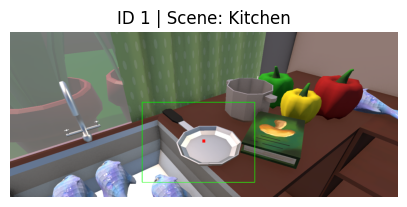

Question: What can I use this object for?
------------------------------------------------------------


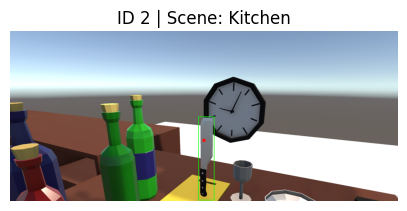

Question: What can I use this object with?
------------------------------------------------------------


In [ ]:
for sample_id in dataset.keys():
    sample = dataset[sample_id]

    image = Image.open(sample["image_path"]).convert("RGB")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f'ID {sample["id"]} | Scene: {sample["scene_type"]}')
    plt.axis("off")
    plt.show()

    print("Question:", sample["question"])
    print("-" * 60)

# **Functions to detect bounding green box**

In [ ]:
def find_green_bbox(image_pil, margin=10, min_area=80, show_debug=False):

    image_np = np.array(image_pil.convert("RGB"))
    h, w = image_np.shape[:2]

    # Convertir a HSV para detectar verde de forma más estable
    hsv = cv2.cvtColor(image_np, cv2.COLOR_RGB2HSV)

    # Rango para verde brillante
    lower_green = np.array([40, 80, 80])
    upper_green = np.array([90, 255, 255])

    green_mask = cv2.inRange(hsv, lower_green, upper_green)

    # Limpiar ruido y conectar líneas del rectángulo verde
    kernel = np.ones((5, 5), np.uint8)
    green_mask = cv2.dilate(green_mask, kernel, iterations=2)
    green_mask = cv2.morphologyEx(green_mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        green_mask,
        connectivity=8
    )

    image_center = np.array([w / 2, h / 2])

    candidates = []

    for label in range(1, num_labels):
        x, y, bw, bh, area = stats[label]
        cx, cy = centroids[label]

        if area < min_area:
            continue

        x_min = x
        y_min = y
        x_max = x + bw
        y_max = y + bh

        bbox_center = np.array([cx, cy])
        distance_to_center = np.linalg.norm(bbox_center - image_center)

        candidates.append({
            "bbox": [x_min, y_min, x_max, y_max],
            "area": area,
            "center": [cx, cy],
            "distance_to_center": distance_to_center
        })

    if len(candidates) == 0:
        print("No se detectó borde verde válido. Usando caja central como fallback.")

        box_w = int(w * 0.35)
        box_h = int(h * 0.35)

        x_min = (w - box_w) // 2
        y_min = (h - box_h) // 2
        x_max = x_min + box_w
        y_max = y_min + box_h

        return [x_min, y_min, x_max, y_max], green_mask

    # Escoger el componente verde más cercano al centro de la imagen
    best_candidate = min(candidates, key=lambda c: c["distance_to_center"])

    x_min, y_min, x_max, y_max = best_candidate["bbox"]

    # Agregar margen
    x_min = max(int(x_min) - margin, 0)
    y_min = max(int(y_min) - margin, 0)
    x_max = min(int(x_max) + margin, w - 1)
    y_max = min(int(y_max) + margin, h - 1)

    selected_bbox = [x_min, y_min, x_max, y_max]

    if show_debug:
        debug_img = image_np.copy()

        for c in candidates:
            bx1, by1, bx2, by2 = c["bbox"]
            cv2.rectangle(debug_img, (bx1, by1), (bx2, by2), (255, 0, 0), 2)

        cv2.rectangle(debug_img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)

        plt.figure(figsize=(8, 5))
        plt.imshow(debug_img)
        plt.title("Detected green components | Selected bbox in green")
        plt.axis("off")
        plt.show()

        print("Candidates:")
        for c in candidates:
            print(c)

        print("Selected bbox:", selected_bbox)

    return selected_bbox, green_mask

# **Functions for SAM**

In [ ]:
def get_mask_bbox(mask, margin=10):
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return None

    h, w = mask.shape

    x_min = max(int(xs.min()) - margin, 0)
    y_min = max(int(ys.min()) - margin, 0)
    x_max = min(int(xs.max()) + margin, w - 1)
    y_max = min(int(ys.max()) + margin, h - 1)

    return [x_min, y_min, x_max, y_max]

In [ ]:
def remove_small_components(mask, min_area=300):

    mask_uint8 = mask.astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask_uint8,
        connectivity=8
    )

    cleaned = np.zeros_like(mask_uint8)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned[labels == label] = 1

    return cleaned.astype(bool)

In [ ]:
def remove_green_pixels_for_sam(image_pil):

    image_np = np.array(image_pil.convert("RGB")).copy()
    hsv = cv2.cvtColor(image_np, cv2.COLOR_RGB2HSV)

    lower_green = np.array([40, 70, 70])
    upper_green = np.array([95, 255, 255])

    green_mask = cv2.inRange(hsv, lower_green, upper_green)

    kernel = np.ones((5, 5), np.uint8)
    green_mask = cv2.dilate(green_mask, kernel, iterations=1)

    # Inpainting para remover borde verde
    cleaned = cv2.inpaint(image_np, green_mask, 3, cv2.INPAINT_TELEA)

    return Image.fromarray(cleaned)

In [ ]:
def keep_component_containing_point(mask, point_xy):

    mask_uint8 = mask.astype(np.uint8)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)

    px, py = point_xy
    px = int(np.clip(px, 0, mask.shape[1] - 1))
    py = int(np.clip(py, 0, mask.shape[0] - 1))

    selected_label = labels[py, px]

    if selected_label == 0:
        # fallback: choose the largest non-background component
        if num_labels <= 1:
            return mask.astype(bool)

        areas = stats[1:, cv2.CC_STAT_AREA]
        largest_label = 1 + np.argmax(areas)
        cleaned_mask = (labels == largest_label)
        return cleaned_mask.astype(bool)

    cleaned_mask = (labels == selected_label)
    return cleaned_mask.astype(bool)

In [ ]:
def create_pretty_overlay(image_pil, mask, color=(0, 255, 0), alpha=0.35, contour_thickness=3):
    image_np = np.array(image_pil).copy()

    if mask.dtype != np.uint8:
        mask_uint8 = (mask.astype(np.uint8) * 255)
    else:
        mask_uint8 = mask.copy()

    result = image_np.copy()

    color_array = np.array(color, dtype=np.uint8)
    result[mask_uint8 > 0] = (
        (1 - alpha) * result[mask_uint8 > 0] + alpha * color_array
    ).astype(np.uint8)

    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(result, contours, -1, color, contour_thickness)

    return Image.fromarray(result)

In [ ]:
def select_best_sam_mask(masks, scores, point_xy, max_area_ratio=0.55, border_penalty=0.20):
    px, py = point_xy
    best_mask = None
    best_score = -1e9

    for i in range(masks.shape[1]):
        mask = masks[0, i].numpy().astype(bool)

        h, w = mask.shape
        area_ratio = mask.sum() / (h * w)

        contains_point = mask[int(py), int(px)]

        # cuánto toca los bordes
        touches_top = mask[0, :].mean()
        touches_bottom = mask[-1, :].mean()
        touches_left = mask[:, 0].mean()
        touches_right = mask[:, -1].mean()

        border_touch = touches_top + touches_bottom + touches_left + touches_right

        sam_score = float(scores[i])

        # Penalizar máscara muy grande
        area_cost = abs(area_ratio - 0.25)

        if area_ratio > max_area_ratio:
            area_cost += 1.5

        # Penalizar si toca muchos bordes
        border_cost = border_touch * border_penalty

        # Requerir que contenga el punto positivo
        point_bonus = 1.0 if contains_point else -2.0

        final_score = sam_score + point_bonus - area_cost - border_cost

        if final_score > best_score:
            best_score = final_score
            best_mask = mask

    return best_mask

In [ ]:
def segment_selected_object_with_sam_after_crop(
    image_pil,
    max_size=(768, 768),
    crop_margin=4,
    inner_shrink=8,
    show_debug=True
):

    # --------------------------------------------------
    # 1. Preparar imagen
    # --------------------------------------------------
    image = image_pil.convert("RGB")
    image.thumbnail(max_size)

    image_np = np.array(image)
    h, w = image_np.shape[:2]

    # --------------------------------------------------
    # 2. Detectar green bbox
    # --------------------------------------------------
    green_bbox, green_mask = find_green_bbox(
        image,
        margin=crop_margin,
        min_area=80,
        show_debug=False
    )

    x_min, y_min, x_max, y_max = green_bbox

    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(w - 1, x_max)
    y_max = min(h - 1, y_max)

    # --------------------------------------------------
    # 3. Crop inicial
    # --------------------------------------------------
    crop_original = image.crop((x_min, y_min, x_max, y_max))
    crop_np = np.array(crop_original)
    crop_h, crop_w = crop_np.shape[:2]

    # --------------------------------------------------
    # 4. Quitar borde verde para SAM
    # --------------------------------------------------
    crop_for_sam = remove_green_pixels_for_sam(crop_original)

    # --------------------------------------------------
    # 5. Prompt para SAM
    # --------------------------------------------------
    # Caja interna para evitar que SAM use el borde verde o el contorno exterior
    crop_box = [
        inner_shrink,
        inner_shrink,
        max(inner_shrink + 1, crop_w - inner_shrink),
        max(inner_shrink + 1, crop_h - inner_shrink)
    ]

    # Punto positivo sobre el objeto.
    # Uso 0.43 de altura para caer en el cuerpo del recipiente y no en la mesa.
    point_x = crop_w // 2
    point_y = int(crop_h * 0.43)

    # Puntos negativos: fondo, mesa, bordes
    negative_points = [
        [int(crop_w * 0.10), int(crop_h * 0.10)],  # esquina superior izquierda
        [int(crop_w * 0.90), int(crop_h * 0.10)],  # esquina superior derecha
        [int(crop_w * 0.10), int(crop_h * 0.90)],  # mesa/fondo inferior izquierda
        [int(crop_w * 0.90), int(crop_h * 0.90)],  # mesa/fondo inferior derecha
        [int(crop_w * 0.50), int(crop_h * 0.92)],  # parte inferior, normalmente mesa
    ]

    all_points = [[point_x, point_y]] + negative_points
    all_labels = [1] + [0] * len(negative_points)

    input_points = [all_points]
    input_labels = [all_labels]

    # --------------------------------------------------
    # 6. Ejecutar SAM
    # --------------------------------------------------
    sam_inputs = sam_processor(
        crop_for_sam,
        input_boxes=[[crop_box]],
        input_points=[input_points],
        input_labels=[input_labels],
        return_tensors="pt"
    )

    sam_inputs = {
        k: v.to(sam_device) if torch.is_tensor(v) else v
        for k, v in sam_inputs.items()
    }

    with torch.no_grad():
        sam_outputs = sam_model(**sam_inputs, multimask_output=True)

    masks = sam_processor.image_processor.post_process_masks(
        sam_outputs.pred_masks.cpu(),
        sam_inputs["original_sizes"].cpu(),
        sam_inputs["reshaped_input_sizes"].cpu()
    )[0]

    scores = sam_outputs.iou_scores.cpu()[0, 0]

    # --------------------------------------------------
    # 7. Seleccionar mejor máscara
    # --------------------------------------------------
    selected_mask = select_best_sam_mask(
        masks=masks,
        scores=scores,
        point_xy=(point_x, point_y),
        max_area_ratio=0.55,
        border_penalty=0.30
    )

    # --------------------------------------------------
    # 8. Limpieza morfológica
    # --------------------------------------------------
    mask_uint8 = (selected_mask.astype(np.uint8) * 255)

    kernel = np.ones((3, 3), np.uint8)
    mask_uint8 = cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel)
    mask_uint8 = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, kernel)

    selected_mask = mask_uint8 > 0
    selected_mask = remove_small_components(
    selected_mask,
    min_area=300
    )

    # --------------------------------------------------
    # 9. Bbox interno de la máscara
    # --------------------------------------------------
    mask_bbox = get_mask_bbox(selected_mask, margin=5)

    # --------------------------------------------------
    # 10. Crear crop segmentado con fondo blanco
    # --------------------------------------------------
    white_background = np.ones_like(crop_np) * 255

    segmented_crop_np = np.where(
        selected_mask[:, :, None],
        crop_np,
        white_background
    )

    segmented_crop = Image.fromarray(segmented_crop_np.astype(np.uint8))

    if mask_bbox is not None:
        mx1, my1, mx2, my2 = mask_bbox
        segmented_crop_tight = segmented_crop.crop((mx1, my1, mx2, my2))
        original_crop_tight = crop_original.crop((mx1, my1, mx2, my2))
    else:
        segmented_crop_tight = segmented_crop
        original_crop_tight = crop_original

    # --------------------------------------------------
    # 11. Pretty overlay
    # --------------------------------------------------
    pretty_overlay_crop = create_pretty_overlay(
        image_pil=crop_original,
        mask=selected_mask,
        color=(0, 255, 0),
        alpha=0.35,
        contour_thickness=3
    )

    # --------------------------------------------------
    # 12. Debug con 4 imágenes
    # --------------------------------------------------
    if show_debug:
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))

        # Imagen completa con bbox
        full_debug = np.array(image).copy()

        cv2.rectangle(
            full_debug,
            (x_min, y_min),
            (x_max, y_max),
            (0, 255, 0),
            3
        )

        axes[0].imshow(full_debug)
        axes[0].set_title("Full image")
        axes[0].axis("off")

        # Crop antes de SAM
        crop_debug = np.array(crop_original).copy()

        cv2.rectangle(
            crop_debug,
            (crop_box[0], crop_box[1]),
            (crop_box[2], crop_box[3]),
            (0, 255, 0),
            2
        )

        # Punto positivo
        cv2.circle(
            crop_debug,
            (point_x, point_y),
            6,
            (255, 0, 0),
            -1
        )

        # Puntos negativos
        for nx, ny in negative_points:
            cv2.circle(
                crop_debug,
                (nx, ny),
                5,
                (0, 0, 255),
                -1
            )

        axes[1].imshow(crop_debug)
        axes[1].set_title("Crop before SAM")
        axes[1].axis("off")

        # Máscara negra
        axes[2].imshow(selected_mask, cmap="gray")
        axes[2].set_title("Black SAM mask")
        axes[2].axis("off")

        # Overlay bonito
        overlay_debug = np.array(pretty_overlay_crop).copy()

        cv2.circle(
            overlay_debug,
            (point_x, point_y),
            6,
            (255, 0, 0),
            -1
        )

        axes[3].imshow(overlay_debug)
        axes[3].set_title("Pretty SAM overlay")
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()

    del sam_inputs, sam_outputs, masks
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "full_image": image,
        "green_bbox": green_bbox,
        "crop_original": crop_original,
        "crop_for_sam": crop_for_sam,
        "crop_box_for_sam": crop_box,
        "positive_point": (point_x, point_y),
        "negative_points": negative_points,
        "mask": selected_mask,
        "mask_bbox_inside_crop": mask_bbox,
        "segmented_crop": segmented_crop,
        "segmented_crop_tight": segmented_crop_tight,
        "original_crop_tight": original_crop_tight,
        "pretty_overlay_crop": pretty_overlay_crop
    }

# **Promp for Qwen**

In [ ]:
def build_vr_prompt(question: str) -> str:
    return f"""
You are an AI assistant inside a VR chemistry laboratory.

You will receive two images:
Image 1: the full VR scene.
Image 2: the segmented crop of the selected object.

The user selected an object highlighted in green in Image 1.
Use Image 2 to identify the selected object more accurately.
Use Image 1 only to understand nearby objects and possible relations.

Your tasks:
1. Identify the selected object.
2. Answer the question in a short, practical way for a chemistry lab.
3. Decide if another object helps use the selected object.

Rules:
- If the question is only identification, for example "What is this?":
  related_object = null
  relation_instruction = null
  related_object_coordinates = null

- If the question is about usage:
  include a related object ONLY if it helps.

- Use realistic and safe lab logic:
  beaker/flask → liquids or chemicals
  burner → heating substances
  pipette → transferring liquids
  thermometer → measuring temperature
  scale → measuring mass

- Avoid unsafe or dangerous instructions.
- Never invent unrealistic or harmful relations.
- Do not describe the whole scene.
- Focus on the selected object.

Coordinates:
- Coordinates must refer to Image 1, the full VR scene.
- Only provide coordinates for the related object.
- Must be a tight bounding box.
- If unsure, use null.
- Never return the full image as a box.

Return ONLY valid JSON.
No markdown.
No explanations.
Do not copy examples.

Example:
{{
  "object": "beaker",
  "answer": "You can use this beaker to hold or mix liquids.",
  "related_object": "burner",
  "relation_instruction": "Place the beaker on the burner to heat the liquid.",
  "related_object_coordinates": {{
    "x_min": 120,
    "y_min": 180,
    "x_max": 320,
    "y_max": 420
  }}
}}

User question:
{question}

JSON:
{{
  "object": "<object>",
  "answer": "<answer>",
  "related_object": "<object or null>",
  "relation_instruction": "<instruction or null>",
  "related_object_coordinates": {{
    "x_min": <int>,
    "y_min": <int>,
    "x_max": <int>,
    "y_max": <int>
  }} or null
}}
"""

In [ ]:
def ask_qwen_with_full_and_crop(full_image, cropped_object, question, max_new_tokens=180):
    prompt = build_vr_prompt(question)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": full_image},
                {"type": "image", "image": cropped_object},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = qwen_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = qwen_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(qwen_model.device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
    ]

    output_text = qwen_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    del inputs, generated_ids, generated_ids_trimmed
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return output_text

In [ ]:
def extract_json_from_response(response_text):

    response_text = response_text.strip()

    try:
        return json.loads(response_text)
    except:
        pass

    start = response_text.find("{")
    end = response_text.rfind("}")

    if start != -1 and end != -1 and end > start:
        json_text = response_text[start:end + 1]

        try:
            return json.loads(json_text)
        except Exception as e:
            print("No se pudo parsear el JSON extraído.")
            print("Error:", e)
            print("Texto extraído:")
            print(json_text)
            return None

    print("No se encontró JSON en la respuesta.")
    return None

# **Inference**

SAMPLE INFORMATION
ID: 1
Scene: Kitchen
Image path: images/pan3.png
Question: What can I use this object for?


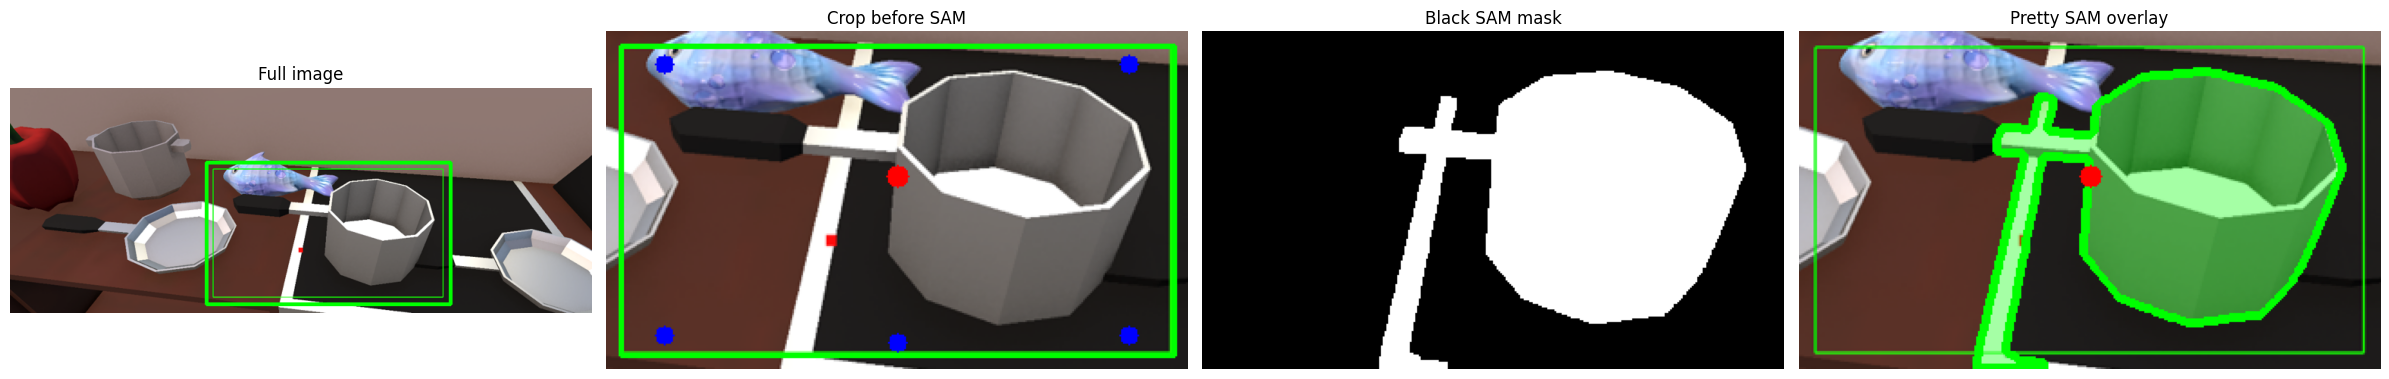


SEGMENTATION INFORMATION
Green bbox: [259, 98, 581, 285]
SAM box inside crop: [8, 8, 314, 179]
Positive point: (161, 80)
Negative points: [[32, 18], [289, 18], [32, 168], [289, 168], [161, 172]]
Mask bbox inside crop: [93, 17, 305, 186]

VISUAL CHECK: SEGMENTATION RESULT


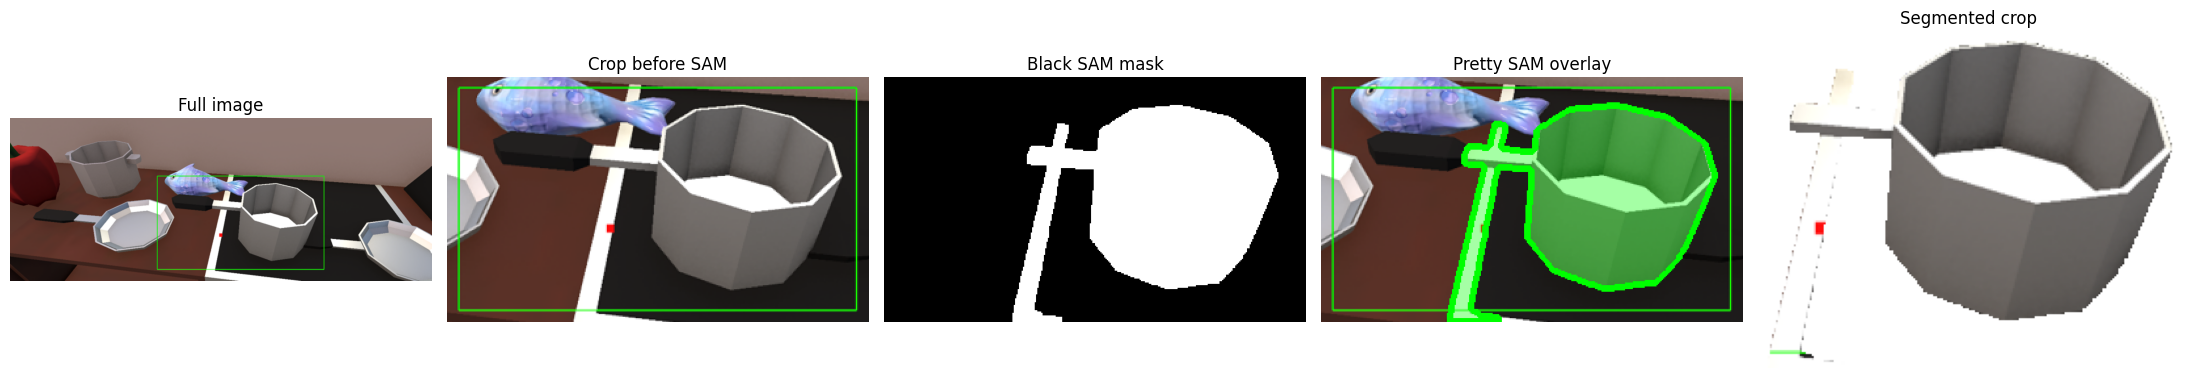


IMAGES SENT TO QWEN


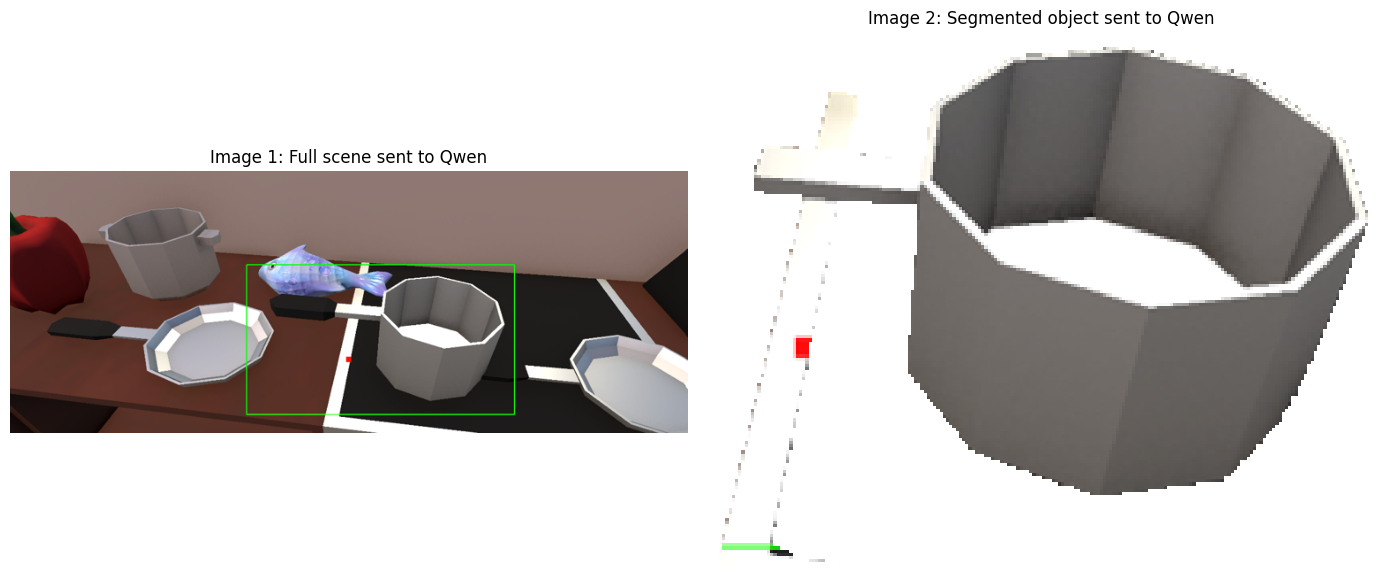


PROMPT SENT TO QWEN

You are an AI assistant inside a VR chemistry laboratory.

You will receive two images:
Image 1: the full VR scene.
Image 2: the segmented crop of the selected object.

The user selected an object highlighted in green in Image 1.
Use Image 2 to identify the selected object more accurately.
Use Image 1 only to understand nearby objects and possible relations.

Your tasks:
1. Identify the selected object.
2. Answer the question in a short, practical way for a chemistry lab.
3. Decide if another object helps use the selected object.

Rules:
- If the question is only identification, for example "What is this?":
  related_object = null
  relation_instruction = null
  related_object_coordinates = null

- If the question is about usage:
  include a related object ONLY if it helps.

- Use realistic and safe lab logic:
  beaker/flask → liquids or chemicals
  burner → heating substances
  pipette → transferring liquids
  thermometer → measuring temperature
  scale → measuri

In [ ]:
# ============================================================
# INFERENCE FOR ONE IMAGE: GREEN BBOX + SAM + QWEN
# ============================================================

sample = dataset[1]   # Cambia este ID para probar otra imagen

image = Image.open(sample["image_path"]).convert("RGB")

print("=" * 80)
print("SAMPLE INFORMATION")
print("=" * 80)
print("ID:", sample["id"])
print("Scene:", sample["scene_type"])
print("Image path:", sample["image_path"])
print("Question:", sample["question"])

# ------------------------------------------------------------
# 1. Run segmentation pipeline
# ------------------------------------------------------------

segmentation_result = segment_selected_object_with_sam_after_crop(
    image_pil=image,
    max_size=(768, 768),
    crop_margin=4,
    inner_shrink=8,
    show_debug=True
)

print("\n" + "=" * 80)
print("SEGMENTATION INFORMATION")
print("=" * 80)
print("Green bbox:", segmentation_result["green_bbox"])
print("SAM box inside crop:", segmentation_result["crop_box_for_sam"])
print("Positive point:", segmentation_result["positive_point"])
print("Negative points:", segmentation_result["negative_points"])
print("Mask bbox inside crop:", segmentation_result["mask_bbox_inside_crop"])

# ------------------------------------------------------------
# 2. Select what will be sent to Qwen
# ------------------------------------------------------------

full_image = segmentation_result["full_image"]

# Opción recomendada si la máscara salió bien:
cropped_object = segmentation_result["segmented_crop_tight"]

# Otras opciones si quieres probar:
# cropped_object = segmentation_result["crop_original"]
# cropped_object = segmentation_result["original_crop_tight"]

crop_original = segmentation_result["crop_original"]
black_mask = segmentation_result["mask"]
pretty_overlay = segmentation_result["pretty_overlay_crop"]
segmented_crop = segmentation_result["segmented_crop_tight"]

# ------------------------------------------------------------
# 3. Show all segmentation outputs
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VISUAL CHECK: SEGMENTATION RESULT")
print("=" * 80)

plt.figure(figsize=(22, 6))

plt.subplot(1, 5, 1)
plt.imshow(full_image)
plt.title("Full image")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(crop_original)
plt.title("Crop before SAM")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(black_mask, cmap="gray")
plt.title("Black SAM mask")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(pretty_overlay)
plt.title("Pretty SAM overlay")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(segmented_crop)
plt.title("Segmented crop")
plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Show exactly what enters Qwen
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGES SENT TO QWEN")
print("=" * 80)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(full_image)
plt.title("Image 1: Full scene sent to Qwen")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_object)
plt.title("Image 2: Segmented object sent to Qwen")
plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Show prompt sent to Qwen
# ------------------------------------------------------------

prompt_preview = build_vr_prompt(sample["question"])

print("\n" + "=" * 80)
print("PROMPT SENT TO QWEN")
print("=" * 80)
print(prompt_preview)

# ------------------------------------------------------------
# 6. Run Qwen inference
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RUNNING QWEN INFERENCE")
print("=" * 80)

response = ask_qwen_with_full_and_crop(
    full_image=full_image,
    cropped_object=cropped_object,
    question=sample["question"],
    max_new_tokens=180
)

# ------------------------------------------------------------
# 7. Print raw response
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RAW MODEL RESPONSE")
print("=" * 80)
print(response)

# ------------------------------------------------------------
# 8. Parse JSON response
# ------------------------------------------------------------

parsed_json = extract_json_from_response(response)

print("\n" + "=" * 80)
print("PARSED JSON")
print("=" * 80)
print(parsed_json)

if parsed_json is not None:
    print("\n" + "=" * 80)
    print("PRETTY JSON")
    print("=" * 80)
    print(json.dumps(parsed_json, indent=2))
else:
    print("The model response could not be parsed as JSON.")

RUNNING PAPER-READY INFERENCE
ID: 1
Scene: Kitchen
Image path: images/pan3.png
Question: What can I use this object for?


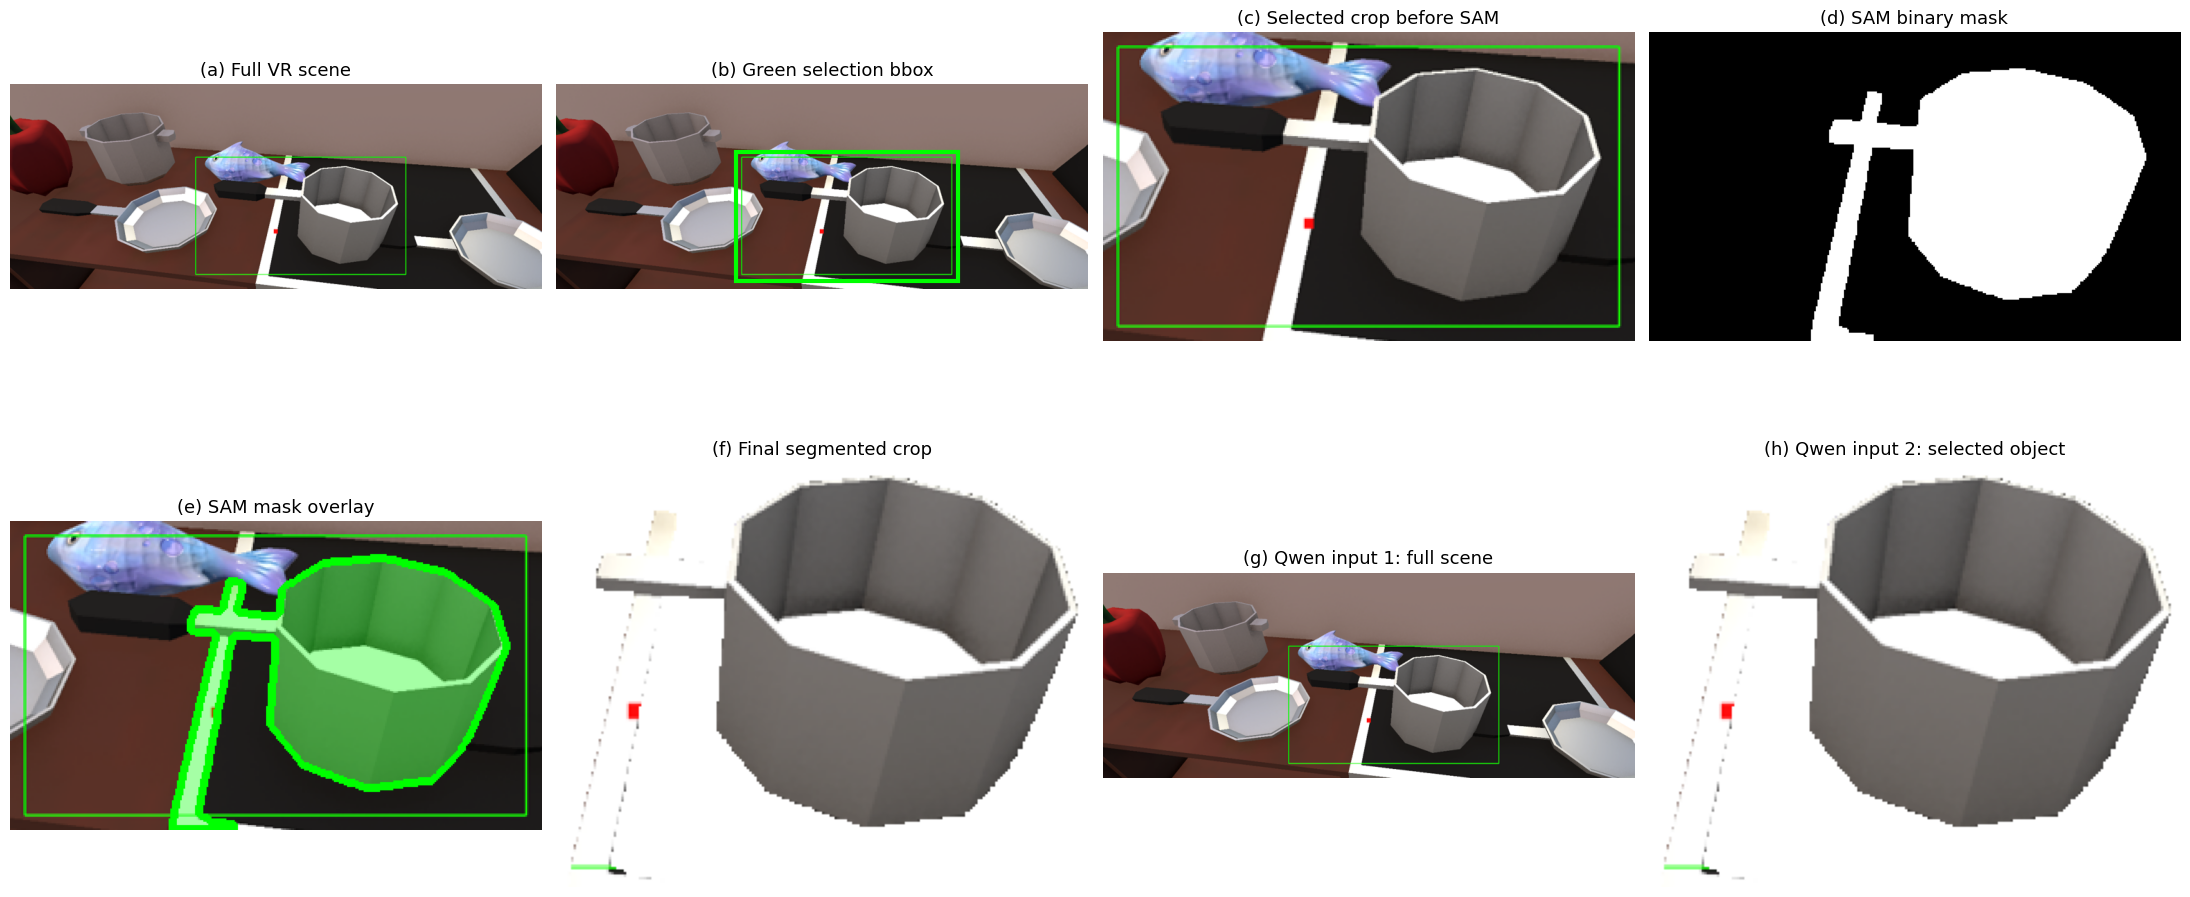

Pipeline figure saved to: paper_outputs/sam_qwen_pipeline_sample_1.png

PROMPT SENT TO QWEN

You are an AI assistant inside a VR chemistry laboratory.

You will receive two images:
Image 1: the full VR scene.
Image 2: the segmented crop of the selected object.

The user selected an object highlighted in green in Image 1.
Use Image 2 to identify the selected object more accurately.
Use Image 1 only to understand nearby objects and possible relations.

Your tasks:
1. Identify the selected object.
2. Answer the question in a short, practical way for a chemistry lab.
3. Decide if another object helps use the selected object.

Rules:
- If the question is only identification, for example "What is this?":
  related_object = null
  relation_instruction = null
  related_object_coordinates = null

- If the question is about usage:
  include a related object ONLY if it helps.

- Use realistic and safe lab logic:
  beaker/flask → liquids or chemicals
  burner → heating substances
  pipette → trans

,sample_id,scene_type,image_path,question,green_bbox,sam_box_inside_crop,positive_point,negative_points,mask_bbox_inside_crop,qwen_input_1,qwen_input_2,predicted_object,answer,related_object,relation_instruction,related_object_coordinates,raw_response
0,1,Kitchen,images/pan3.png,What can I use this object for?,"[259, 98, 581, 285]","[8, 8, 314, 179]","(161, 80)","[[32, 18], [289, 18], [32, 168], [289, 168], [...","[93, 17, 305, 186]",full_scene,segmented_crop,beaker,You can use this beaker to hold or mix liquids.,pipette,Transfer the liquid from the beaker using the ...,"{'x_min': 50, 'y_min': 200, 'x_max': 150, 'y_m...","```json\n{\n ""object"": ""beaker"",\n ""answer"":..."


Result table saved to: paper_outputs/sam_qwen_result_sample_1.csv


In [ ]:
# ============================================================
# PAPER-READY INFERENCE: SAM PIPELINE + QWEN INPUT + RESULTS TABLE
# ============================================================

import os
import json
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

output_dir = "paper_outputs"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Select sample
# ------------------------------------------------------------

sample = dataset[1]   # Cambia el ID si quieres probar otra imagen

image = Image.open(sample["image_path"]).convert("RGB")

print("=" * 90)
print("RUNNING PAPER-READY INFERENCE")
print("=" * 90)
print("ID:", sample["id"])
print("Scene:", sample["scene_type"])
print("Image path:", sample["image_path"])
print("Question:", sample["question"])

# ------------------------------------------------------------
# 2. Run SAM segmentation pipeline
# ------------------------------------------------------------

segmentation_result = segment_selected_object_with_sam_after_crop(
    image_pil=image,
    max_size=(768, 768),
    crop_margin=4,
    inner_shrink=8,
    show_debug=False
)

# ------------------------------------------------------------
# 3. Extract images from SAM pipeline
# ------------------------------------------------------------

full_image = segmentation_result["full_image"]
green_bbox = segmentation_result["green_bbox"]

crop_original = segmentation_result["crop_original"]
black_mask = segmentation_result["mask"]
pretty_overlay = segmentation_result["pretty_overlay_crop"]
segmented_crop = segmentation_result["segmented_crop_tight"]

# Imagen que entrará a Qwen
# Recomendado si la máscara salió bien:
qwen_crop = segmentation_result["segmented_crop_tight"]

# Si SAM corta demasiado el objeto, cambia por:
# qwen_crop = segmentation_result["crop_original"]
# qwen_crop = segmentation_result["original_crop_tight"]

# ------------------------------------------------------------
# 4. Show matrix of images for paper
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(22, 11))

# -------------------------
# View 1: Full image
# -------------------------
axes[0, 0].imshow(full_image)
axes[0, 0].set_title("(a) Full VR scene", fontsize=13)
axes[0, 0].axis("off")

# -------------------------
# View 2: Green bbox
# -------------------------
axes[0, 1].imshow(full_image)
x_min, y_min, x_max, y_max = green_bbox
rect = patches.Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    linewidth=3,
    edgecolor="lime",
    facecolor="none"
)
axes[0, 1].add_patch(rect)
axes[0, 1].set_title("(b) Green selection bbox", fontsize=13)
axes[0, 1].axis("off")

# -------------------------
# View 3: Crop before SAM
# -------------------------
axes[0, 2].imshow(crop_original)
axes[0, 2].set_title("(c) Selected crop before SAM", fontsize=13)
axes[0, 2].axis("off")

# -------------------------
# View 4: Black SAM mask
# -------------------------
axes[0, 3].imshow(black_mask, cmap="gray")
axes[0, 3].set_title("(d) SAM binary mask", fontsize=13)
axes[0, 3].axis("off")

# -------------------------
# View 5: Pretty SAM overlay
# -------------------------
axes[1, 0].imshow(pretty_overlay)
axes[1, 0].set_title("(e) SAM mask overlay", fontsize=13)
axes[1, 0].axis("off")

# -------------------------
# View 6: Segmented crop
# -------------------------
axes[1, 1].imshow(segmented_crop)
axes[1, 1].set_title("(f) Final segmented crop", fontsize=13)
axes[1, 1].axis("off")

# -------------------------
# View 7: Full image sent to Qwen
# -------------------------
axes[1, 2].imshow(full_image)
axes[1, 2].set_title("(g) Qwen input 1: full scene", fontsize=13)
axes[1, 2].axis("off")

# -------------------------
# View 8: Object crop sent to Qwen
# -------------------------
axes[1, 3].imshow(qwen_crop)
axes[1, 3].set_title("(h) Qwen input 2: selected object", fontsize=13)
axes[1, 3].axis("off")

plt.tight_layout()

figure_path = os.path.join(
    output_dir,
    f"sam_qwen_pipeline_sample_{sample['id']}.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Pipeline figure saved to:", figure_path)

# ------------------------------------------------------------
# 5. Show prompt sent to Qwen
# ------------------------------------------------------------

prompt_preview = build_vr_prompt(sample["question"])

print("\n" + "=" * 90)
print("PROMPT SENT TO QWEN")
print("=" * 90)
print(prompt_preview)

# ------------------------------------------------------------
# 6. Run Qwen inference
# ------------------------------------------------------------

response = ask_qwen_with_full_and_crop(
    full_image=full_image,
    cropped_object=qwen_crop,
    question=sample["question"],
    max_new_tokens=180
)

parsed_json = extract_json_from_response(response)

print("\n" + "=" * 90)
print("RAW QWEN RESPONSE")
print("=" * 90)
print(response)

print("\n" + "=" * 90)
print("PARSED JSON")
print("=" * 90)

if parsed_json is not None:
    print(json.dumps(parsed_json, indent=2))
else:
    print("Could not parse response as JSON.")

# ------------------------------------------------------------
# 7. Create results table
# ------------------------------------------------------------

if parsed_json is None:
    object_name = None
    answer = None
    related_object = None
    relation_instruction = None
    related_object_coordinates = None
else:
    object_name = parsed_json.get("object")
    answer = parsed_json.get("answer")
    related_object = parsed_json.get("related_object")
    relation_instruction = parsed_json.get("relation_instruction")
    related_object_coordinates = parsed_json.get("related_object_coordinates")

results_row = {
    "sample_id": sample["id"],
    "scene_type": sample["scene_type"],
    "image_path": sample["image_path"],
    "question": sample["question"],
    "green_bbox": segmentation_result["green_bbox"],
    "sam_box_inside_crop": segmentation_result["crop_box_for_sam"],
    "positive_point": segmentation_result["positive_point"],
    "negative_points": segmentation_result["negative_points"],
    "mask_bbox_inside_crop": segmentation_result["mask_bbox_inside_crop"],
    "qwen_input_1": "full_scene",
    "qwen_input_2": "segmented_crop",
    "predicted_object": object_name,
    "answer": answer,
    "related_object": related_object,
    "relation_instruction": relation_instruction,
    "related_object_coordinates": related_object_coordinates,
    "raw_response": response
}

df_inference = pd.DataFrame([results_row])

print("\n" + "=" * 90)
print("RESULT TABLE")
print("=" * 90)

display(df_inference)

# ------------------------------------------------------------
# 8. Save table as CSV
# ------------------------------------------------------------

table_path = os.path.join(
    output_dir,
    f"sam_qwen_result_sample_{sample['id']}.csv"
)

df_inference.to_csv(table_path, index=False)

print("Result table saved to:", table_path)